# Modes of a Ring Resonator

In Tutorial/Basics/Modes of a Ring Resonator, the modes of a ring resonator were computed by performing a 2d simulation. This example involves simulating the same structure while exploiting the fact that the system has continuous rotational symmetry, by performing the simulation in cylindrical coordinates. 

As always, the starting point is to import the meep and other library modules:

In [24]:
import meep as mp
import argparse
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


The parameters of the problem are defined with exactly the same values as in the 2d simulation:

In [25]:
n = 3.4     # index of waveguide
w = 1       # width of waveguide
r = 1       # inner radius of ring
pad = 4     # padding between waveguide and edge of PML
dpml = 2    # thickness of PML

The dimensions and size of the computational cell are defined:

In [26]:
sr = r + w + pad + dpml         # radial size (cell is from 0 to sr)
dimensions = mp.CYLINDRICAL
cell = mp.Vector3(sr, 0, 0)

The key thing is to set the dimensions parameter to **CYLINDRICAL**. This means that all vectors represent (r
,ϕ
,z
) coordinates instead of (x
,y
,z
). The computational cell in the r
 direction is of size **sr = r + w + pad + dpml**, and runs from 0 to sr (by default) rather than from **-sr/2** to **sr/2** as it would for any other dimension. Note that the z
 size is 0 because it is in 2d. The ϕ
 size is also 0, corresponding to the continuous rotational symmetry. A finite ϕ
 size might correspond to discrete rotational symmetry, but this is not currently supported.

In particular, in systems with continuous rotational symmetry, by an analogue of Bloch's theorem, the angular dependence of the fields can always be chosen in the form exp(imϕ)
 for some integer m
. Meep uses this fact to treat the angular dependence analytically, with m
 given by the input variable m which is set to a command-line argument that is 3 by default.

The geometry is now specified by a single **Block** object — remember that this is a block in cylindrical coordinates, so that it really specifies an annular ring:

In [27]:
geometry = [mp.Block(center=mp.Vector3(r + (w / 2)),
                     size=mp.Vector3(w, 1e20, 1e20),
                     material=mp.Medium(index=n))]

pml_layers = [mp.PML(dpml)]
resolution = 10

PMLs are on "all" sides. The z
 direction has no thickness and therefore it is automatically periodic with no PML. PML is also omitted from the boundary at r
=0 which is handled by the analytical reflection symmetry.

The remaining inputs are almost exactly the same as in the previous 2d simulation. A single Gaussian point source is added in the z
 direction to excite Ez
-polarized modes, with some center frequency and width:

In [28]:
fcen    = 0.15  # pulse center frequency
df      = 0.1   # pulse width (in frequency)
m       = 3     # phi (angular) dependence of the fields given by exp(i m phi)

sources = [mp.Source(src=mp.GaussianSource(fcen, fwidth=df),
                     component=mp.Ez,
                     center=mp.Vector3(r + 0.1))]

Note that this isn't really a point source, however, because of the **cylindrical symmetry**—it is really a **ring source** with a $\phi$ dependence of $\exp(im\phi)$.

Finally, as before, the fields are time-stepped until the source has turned off, plus 200 additional time units. During this time, `Harminv` is used to analyze the $E_z$ field at a given point to extract the **frequencies and decay rates** of the modes.

In [29]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    boundary_layers=pml_layers,
                    resolution=resolution,
                    sources=sources,
                    dimensions=dimensions,
                    m=m)

### Run simulation

In [ ]:
sim.run(mp.after_sources(mp.Harminv(mp.Ez, mp.Vector3(r + 0.1), fcen, df)),
        until_after_sources=200)

At the very end, one period of the fields is output to create an animation. A single field output would be a 1D dataset along the **$r$** direction, so to make things more interesting `to_appended` is used to append these datasets to a single HDF5 file to obtain an **$r \times t$** 2D dataset.

Also, `in_volume` is used to specify a larger output volume than just the computational cell: in particular, the output is from **$-s_r$ to $s_r$** in the **$r$** direction, where the **$-r$** field values are automatically inferred from the reflection symmetry.

In [ ]:
sim.run(mp.in_volume(mp.Volume(center=mp.Vector3(), size=mp.Vector3(2 * sr)),
                     mp.at_beginning(mp.output_epsilon),
                     mp.to_appended("ez", mp.at_every(1 / fcen / 20, mp.output_efield_z))),
        until=1 / fcen)

visualization

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob

def h5_to_png(data_file, eps_file, output_filename="ez_rt_plot.png", scale=2):
    """
    Replicates the functionality of Meep's h5topng to create a PNG image
    from HDF5 data files.

    Args:
        data_file (str): Path to the HDF5 file containing the field data (e.g., ez.h5).
        eps_file (str): Path to the HDF5 file containing the epsilon data for contours.
        output_filename (str): Name of the output PNG file.
        scale (float): Scaling factor for the output image resolution.
    """
    print(f"--- Reading data from '{os.path.basename(data_file)}' ---")
    print(f"--- Reading geometry from '{os.path.basename(eps_file)}' ---")

    try:
        # --- 1. Read Field and Geometry Data ---
        with h5py.File(data_file, 'r') as f:
            # The dataset is named 'ez' inside the file
            field_data = f['ez'][:]  # This will be an (r, t) array

        with h5py.File(eps_file, 'r') as f:
            eps_data = f['epsilon'][:]
            # The coordinates are stored as an attribute
            r_coords = f['epsilon'].attrs['x']
    except (FileNotFoundError, KeyError, OSError) as e:
        print(f"Error: Could not read HDF5 files. Details: {e}")
        return

    # The time steps are not explicitly saved, so we create a time axis
    num_time_steps = field_data.shape[1]
    time_coords = np.arange(num_time_steps)

    # --- 2. Set up the Plot ---
    # Use figsize and dpi to control the output image size (replicates -S flag)
    fig, ax = plt.subplots(figsize=(5 * scale, 4 * scale), dpi=100)

    # --- 3. Plot the Field Data ---
    # Determine the absolute maximum for a symmetric colormap (replicates -Zc)
    max_abs_val = np.max(np.abs(field_data))
    
    # Use pcolormesh for a 2D plot. Transpose data to have time on the x-axis.
    # Use the 'RdBu' colormap, which is similar to 'dkbluered'.
    im = ax.pcolormesh(
        time_coords,
        r_coords,
        field_data,
        cmap='RdBu',
        vmin=-max_abs_val,
        vmax=max_abs_val,
        shading='gouraud'
    )

    # --- 4. Overlay Geometry Contours ---
    # The epsilon data is 1D, so we create a 2D grid for the contour plot
    # where the epsilon value is constant along the time axis.
    eps_grid_2d, _ = np.meshgrid(eps_data, time_coords, indexing='ij')
    
    # Draw contour lines where the dielectric constant changes
    ax.contour(
        time_coords,
        r_coords,
        eps_grid_2d,
        levels=np.unique(eps_data), # Draw lines at each unique epsilon value
        colors='k',      # Black contours
        linewidths=1.0,
        linestyles='--'
    )

    # --- 5. Formatting and Saving ---
    ax.set_title("Ez Field vs. Radius and Time")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Radius (r)")
    
    cbar = fig.colorbar(im)
    cbar.set_label("Electric Field (Ez)")
    
    plt.tight_layout()
    plt.savefig(output_filename)
    print(f"--- Successfully saved plot to '{output_filename}' ---")
    plt.close(fig)

#### Use h5_to_png

In [ ]:
output_dir = f"./"

data_filepath = os.path.join(output_dir, f"ez.h5")
    
# Find the epsilon file using a wildcard, as its name includes a timestamp
eps_files = glob.glob(os.path.join(output_dir, f"eps-*.h5"))
    
if not os.path.exists(data_filepath) or not eps_files:
    print("Error: HDF5 files not found. Please run the simulation script first.")
else:
    eps_filepath = eps_files[0]
    output_image_path = os.path.join(output_dir, "ez_rt_plot.png")
        
    # Call the function to generate the plot
    h5_to_png(data_filepath, eps_filepath, output_image_path, scale=2)

## Show the geometry

In [30]:
import pyvista as pv
import meep as mp

def visualize_meep_geometry_cylindrical(geometry, show_material=True, opacity=0.6):
    """
    Enhanced visualization of Meep geometry in cylindrical coordinates using PyVista.
    
    Supports: mp.Block, mp.Cylinder, mp.Sphere, mp.Cone
    Cylindrical assumption: Blocks/Cylinders are oriented along z-axis.
    """
    plotter = pv.Plotter()
    
    for obj in geometry:
        # --- Choose color based on material ---
        if not show_material:
            color = "gray"
        else:
            if obj.material == mp.metal:
                color = "silver"
            elif isinstance(obj.material, mp.Medium):
                # Assign color based on epsilon (dielectric)
                if hasattr(obj.material, "epsilon_diag"):
                    color = "green"
                else:
                    color = "lightblue"
            else:
                color = "lightblue"  # default for unknown
        
        # --- Handle geometry types ---
        if isinstance(obj, mp.Block):
            sx, sy, sz = obj.size.x, obj.size.y, obj.size.z
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            sy = sy if sy > 0 else 0.01  # avoid degenerate
            block = pv.Cube(center=(cx, cy, cz), x_length=sx, y_length=sy, z_length=sz)
            plotter.add_mesh(block, opacity=opacity, color=color, show_edges=True)
        
        elif isinstance(obj, mp.Cylinder):
            r = obj.radius
            h = obj.height
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            cyl = pv.Cylinder(center=(cx, cy, cz), radius=r, height=h, direction=(0,0,1))
            plotter.add_mesh(cyl, opacity=opacity, color=color, show_edges=True)
        
        elif isinstance(obj, mp.Sphere):
            r = obj.radius
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            sph = pv.Sphere(radius=r, center=(cx, cy, cz))
            plotter.add_mesh(sph, opacity=opacity, color=color, show_edges=True)
        
        elif isinstance(obj, mp.Cone):
            r1 = obj.radius
            r2 = getattr(obj, "radius2", 0)
            h  = obj.height
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            # Base cone (pointing up along z)
            cone = pv.Cone(center=(cx, cy, cz - h/2), direction=(0,0,1),
                           height=h, radius=r1, capping=True)
            if r2 > 0:
                # Frustum (cut top)
                top_cone = pv.Cone(center=(cx, cy, cz - h/2), direction=(0,0,1),
                                   height=h, radius=r2, capping=True)
                cone = cone.boolean_cut(top_cone)
            plotter.add_mesh(cone, opacity=opacity, color=color, show_edges=True)
        
        else:
            print(f"⚠️ Unsupported geometry type: {type(obj)}")
    
    # --- Enhancements ---
    plotter.show_grid()
    plotter.add_axes(line_width=2)
    plotter.enable_eye_dome_lighting()
    plotter.show(cpos="iso")


In [ ]:
geometry = [
    mp.Block(center=mp.Vector3(2.5,0,0), size=mp.Vector3(1,1,2), material=mp.Medium(index=3.4)),
    mp.Cylinder(center=mp.Vector3(5,0,1), radius=0.5, height=2, material=mp.Medium(index=2.0))
]

visualize_meep_geometry_cylindrical(geometry)


In [ ]:
import meep as mp

# Define hollow horn geometry
geometry = []

# Outer horn (cone)
outer_radius = 2.0    # base radius
top_radius = 0.5      # tip radius
height = 5.0
center_z = height / 2  # so that base is at z=0

outer_cone = mp.Cone(center=mp.Vector3(0,0,center_z),
                     radius=outer_radius,
                     radius2=top_radius,
                     height=height,
                     material=mp.Medium(index=3.4))  # horn material
geometry.append(outer_cone)

# Inner hollow (air) -> slightly smaller radius to create wall thickness
wall_thickness = 0.2
inner_cone = mp.Cone(center=mp.Vector3(0,0,center_z),
                     radius=outer_radius - wall_thickness,
                     radius2=top_radius - wall_thickness,
                     height=height,
                     material=mp.Medium(index=1.0))  # air
geometry.append(inner_cone)

# Visualize using the enhanced function
visualize_meep_geometry_cylindrical(geometry, show_material=True)


/opt/anaconda3/envs/meep/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/opt/anaconda3/envs/meep/lib/python3.13/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


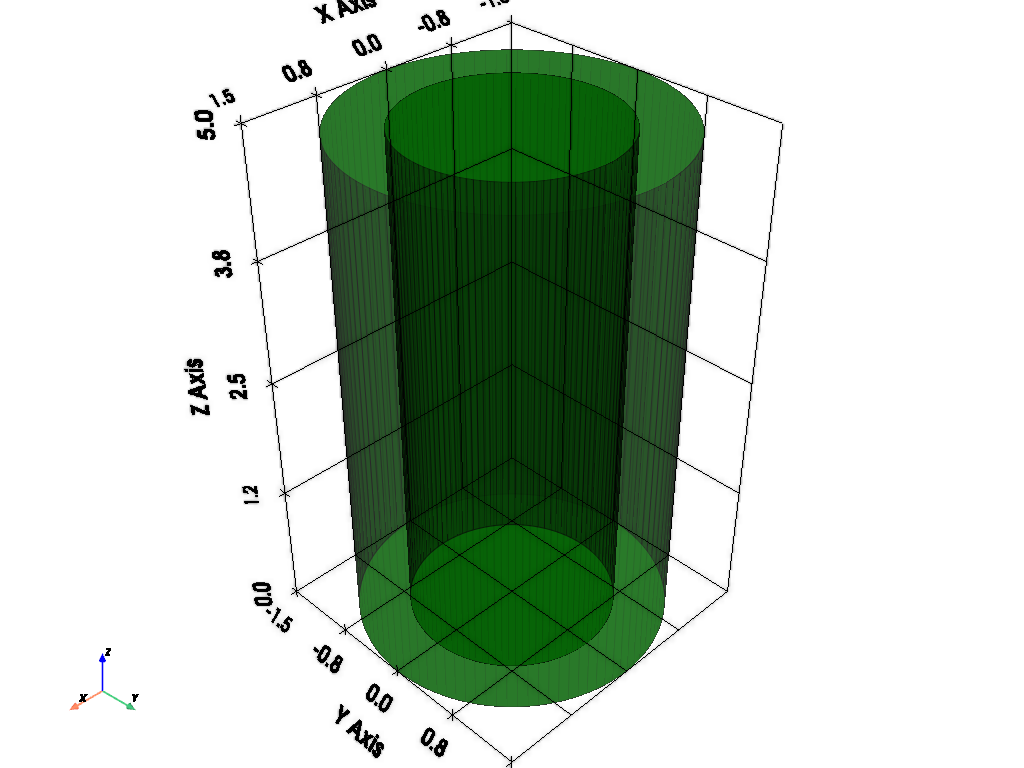

In [31]:
import meep as mp

# Define hollow horn geometry
geometry = []

# Horn parameters
base_outer_radius = 1.5   # smaller base outer radius
base_inner_radius = 1.0   # smaller base inner radius (hollow)
top_outer_radius = 18.0    # top outer radius (flare)
top_inner_radius = 3.5    # top inner radius
height = 5.0
center_z = height / 2     # so base is at z=0

# Outer cone (horn material)
outer_cone = mp.Cone(center=mp.Vector3(0,0,center_z),
                     radius=base_outer_radius,
                     radius2=top_outer_radius,
                     height=height,
                     material=mp.Medium(index=3.4))
geometry.append(outer_cone)

# Inner cone (hollow)
inner_cone = mp.Cone(center=mp.Vector3(0,0,center_z),
                     radius=base_inner_radius,
                     radius2=top_inner_radius,
                     height=height,
                     material=mp.Medium(index=1.0))  # air
geometry.append(inner_cone)

# Visualize
visualize_meep_geometry_cylindrical(geometry, show_material=True)


In [32]:
import pyvista as pv
import meep as mp

def visualize_meep_geometry_cylindrical_full(geometry, show_material=True, opacity=0.6):
    """
    Visualize a Meep geometry list in cylindrical coordinates using PyVista.
    Supports: mp.Block, mp.Cylinder, mp.Sphere, mp.Cone (hollow), mp.Prism.
    Handles multiple components together.
    """
    plotter = pv.Plotter()
    
    # First, process cones separately for hollow subtraction
    cones = [obj for obj in geometry if isinstance(obj, mp.Cone)]
    non_cones = [obj for obj in geometry if not isinstance(obj, mp.Cone)]
    
    # Plot non-cone objects
    for obj in non_cones:
        # Determine color
        if not show_material:
            color = "gray"
        else:
            if obj.material == mp.metal:
                color = "silver"
            elif isinstance(obj.material, mp.Medium):
                color = "green" if getattr(obj.material, "epsilon_diag", None) else "lightblue"
            else:
                color = "lightblue"
        
        if isinstance(obj, mp.Block):
            sx, sy, sz = obj.size.x, obj.size.y, obj.size.z
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            sy = sy if sy > 0 else 0.01
            block = pv.Cube(center=(cx, cy, cz), x_length=sx, y_length=sy, z_length=sz)
            plotter.add_mesh(block, opacity=opacity, color=color, show_edges=True)
        
        elif isinstance(obj, mp.Cylinder):
            r = obj.radius
            h = obj.height
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            cyl = pv.Cylinder(center=(cx, cy, cz), radius=r, height=h, direction=(0,0,1))
            plotter.add_mesh(cyl, opacity=opacity, color=color, show_edges=True)
        
        elif isinstance(obj, mp.Sphere):
            r = obj.radius
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            sph = pv.Sphere(radius=r, center=(cx, cy, cz))
            plotter.add_mesh(sph, opacity=opacity, color=color, show_edges=True)
        
        elif isinstance(obj, mp.Prism):
            # Create a polygonal prism
            vertices = [(v.x, v.y) for v in obj.vertices]  # base polygon
            height = obj.height
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            prism = pv.Extrude(pv.Polygon(vertices), direction=(0,0,1), scale=height)
            prism.translate((cx, cy, cz - height/2))
            plotter.add_mesh(prism, opacity=opacity, color=color, show_edges=True)
        
        else:
            print(f"⚠️ Unsupported object: {type(obj)}")
    
    # Now handle cones (hollow included)
    outer_cones = [c for c in cones if getattr(c.material, "index", 0) > 1.0]
    inner_cones = [c for c in cones if getattr(c.material, "index", 0) <= 1.0]  # air
    
    for outer in outer_cones:
        cx, cy, cz = outer.center.x, outer.center.y, outer.center.z
        r1 = outer.radius
        r2 = getattr(outer, "radius2", 0)
        h = outer.height
        
        outer_mesh = pv.Cone(center=(cx, cy, cz - h/2), direction=(0,0,1), height=h, radius=r1, capping=True)
        
        # Subtract any matching inner cones
        for inner in inner_cones:
            if inner.center == outer.center and inner.height == outer.height:
                r_inner1 = inner.radius
                r_inner2 = getattr(inner, "radius2", 0)
                inner_mesh = pv.Cone(center=(cx, cy, cz - h/2), direction=(0,0,1),
                                     height=h, radius=r_inner1, capping=True)
                outer_mesh = outer_mesh.boolean_difference(inner_mesh, tolerance=1e-5)
        
        # Assign color
        if not show_material:
            color = "gray"
        else:
            color = "green"
        
        plotter.add_mesh(outer_mesh, opacity=opacity, color=color, show_edges=True)
    
    # Finalize
    plotter.show_grid()
    plotter.add_axes(line_width=2)
    plotter.enable_eye_dome_lighting()
    plotter.show(cpos="iso")


In [33]:
geometry = []

# Hollow horn
geometry.append(mp.Cone(center=mp.Vector3(0,0,2.5),
                        radius=1.5, radius2=18.0, height=5.0,
                        material=mp.Medium(index=3.4)))  # horn material

geometry.append(mp.Cone(center=mp.Vector3(0,0,2.5),
                        radius=1.0, radius2=3.5, height=5.0,
                        material=mp.Medium(index=1.0)))  # hollow inside

# Cylinder
geometry.append(mp.Cylinder(center=mp.Vector3(5,0,2.5), radius=1, height=3,
                            material=mp.Medium(index=2.0)))

# Block
geometry.append(mp.Block(center=mp.Vector3(-5,0,1.5), size=mp.Vector3(2,2,3),
                         material=mp.Medium(index=2.5)))


/opt/anaconda3/envs/meep/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/opt/anaconda3/envs/meep/lib/python3.13/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


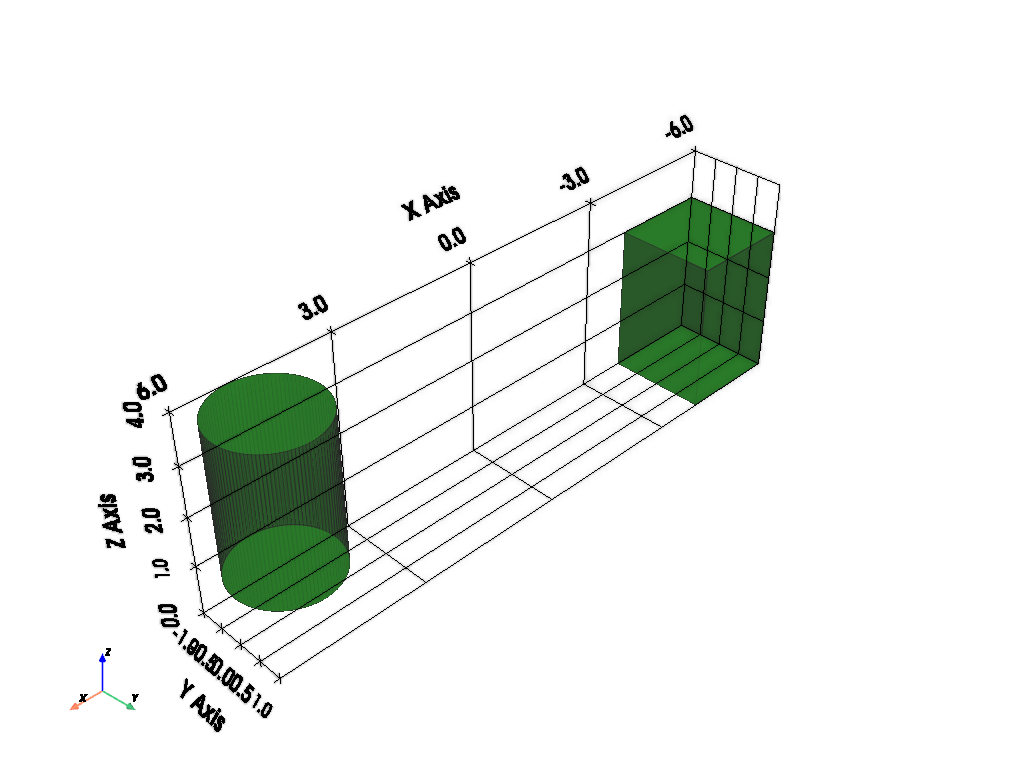

In [34]:
visualize_meep_geometry_cylindrical_full(geometry, show_material=True, opacity=0.6)


In [35]:
import meep as mp

# Define hollow horn geometry
geometry = []

# Horn parameters
base_outer_radius = 1.5   # smaller base outer radius
base_inner_radius = 1.0   # smaller base inner radius (hollow)
top_outer_radius = 18.0    # top outer radius (flare)
top_inner_radius = 3.5    # top inner radius
height = 5.0
center_z = height / 2     # so base is at z=0

# Outer cone (horn material)
outer_cone = mp.Cone(center=mp.Vector3(0,0,center_z),
                     radius=base_outer_radius,
                     radius2=top_outer_radius,
                     height=height,
                     material=mp.Medium(index=3.4))
geometry.append(outer_cone)

# Inner cone (hollow)
inner_cone = mp.Cone(center=mp.Vector3(0,0,center_z),
                     radius=base_inner_radius,
                     radius2=top_inner_radius,
                     height=height,
                     material=mp.Medium(index=1.0))  # air
geometry.append(inner_cone)




In [36]:
import pyvista as pv
pv.set_jupyter_backend('none')

# Visualize
visualize_meep_geometry_cylindrical_full(geometry, show_material=True, opacity=0.6)

In [37]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

def meep_geometry_to_2d_crosssection(geometry, r_range=(0,10), z_range=(0,10), resolution=400):
    """
    Create a 2D r-z cross section of general Meep geometry in cylindrical coordinates.
    
    Supports: Block, Cylinder, Cone, Sphere, Prism
    """
    r_min, r_max = r_range
    z_min, z_max = z_range
    r = np.linspace(r_min, r_max, resolution)
    z = np.linspace(z_min, z_max, resolution)
    R, Z = np.meshgrid(r, z, indexing='ij')
    
    # Background permittivity (air)
    eps = np.ones_like(R)
    
    for obj in geometry:
        # Determine refractive index
        if isinstance(obj.material, mp.Medium):
            n = getattr(obj.material, 'index', 1.0)
        else:
            n = 1.0
        
        # --- Block ---
        if isinstance(obj, mp.Block):
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            sx, sy, sz = obj.size.x, obj.size.y, obj.size.z
            # Cylindrical coordinates
            r0 = np.sqrt(cx**2 + cy**2)
            mask_r = (R >= r0 - sx/2) & (R <= r0 + sx/2)
            mask_z = (Z >= cz - sz/2) & (Z <= cz + sz/2)
            eps[mask_r & mask_z] = n**2
        
        # --- Cylinder ---
        elif isinstance(obj, mp.Cylinder):
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            radius = obj.radius
            height = obj.height
            r0 = np.sqrt(cx**2 + cy**2)
            mask_r = (R >= r0 - radius) & (R <= r0 + radius)
            mask_z = (Z >= cz - height/2) & (Z <= cz + height/2)
            eps[mask_r & mask_z] = n**2
        
        # --- Cone (hollow or full) ---
        elif isinstance(obj, mp.Cone):
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            h = obj.height
            r1 = obj.radius      # bottom radius
            r2 = getattr(obj, "radius2", 0)  # top radius
            for i in range(resolution):
                for j in range(resolution):
                    zval = Z[i,j]
                    if cz - h/2 <= zval <= cz + h/2:
                        # linear interpolation of radius at this z
                        t = (zval - (cz - h/2)) / h
                        radius_z = r1 + t*(r2 - r1)
                        rval = R[i,j]
                        if rval <= radius_z:
                            eps[i,j] = n**2
        
        # --- Sphere ---
        elif isinstance(obj, mp.Sphere):
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            radius = obj.radius
            r0 = np.sqrt(cx**2 + cy**2)
            mask = ((R - r0)**2 + (Z - cz)**2) <= radius**2
            eps[mask] = n**2
        
        # --- Prism ---
        elif isinstance(obj, mp.Prism):
            # approximate prism as vertical extruded polygon
            cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
            height = obj.height
            r0 = np.sqrt(cx**2 + cy**2)
            # Simple approximation: fill R in bounding radius
            max_dist = max(np.sqrt(v.x**2 + v.y**2) for v in obj.vertices)
            mask_r = (R >= r0 - max_dist) & (R <= r0 + max_dist)
            mask_z = (Z >= cz - height/2) & (Z <= cz + height/2)
            eps[mask_r & mask_z] = n**2
        
        else:
            print(f"⚠️ Unsupported geometry type: {type(obj)}")
    
    # --- Plot ---
    plt.figure(figsize=(6,8))
    plt.pcolormesh(Z, R, eps, shading='auto', cmap='viridis')
    plt.xlabel("z")
    plt.ylabel("r")
    plt.title("r-z cross-section (permittivity)")
    plt.colorbar(label="ε (permittivity)")
    plt.show()


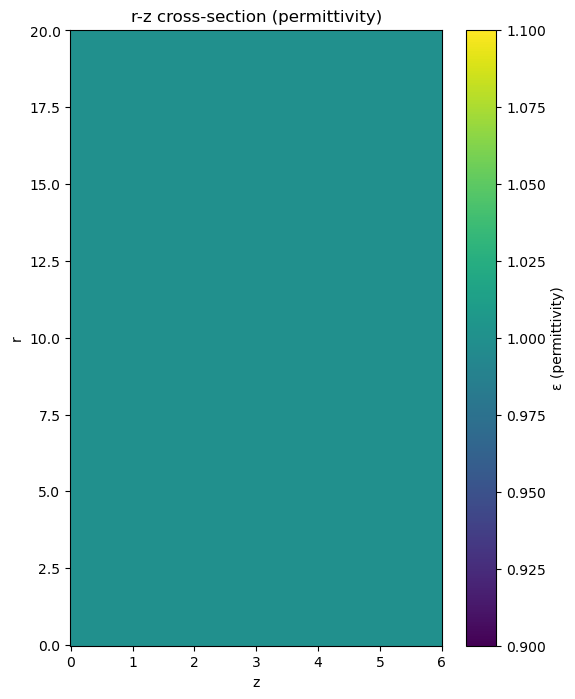

In [38]:
geometry = []

# Hollow horn
geometry.append(mp.Cone(center=mp.Vector3(0,0,2.5),
                        radius=1.5, radius2=18.0, height=5.0,
                        material=mp.Medium(index=3.4)))
geometry.append(mp.Cone(center=mp.Vector3(0,0,2.5),
                        radius=1.0, radius2=3.5, height=5.0,
                        material=mp.Medium(index=1.0)))  # hollow

# Cylinder
geometry.append(mp.Cylinder(center=mp.Vector3(5,0,2.5), radius=1, height=3,
                            material=mp.Medium(index=2.0)))

# Block
geometry.append(mp.Block(center=mp.Vector3(-5,0,1.5), size=mp.Vector3(2,2,3),
                         material=mp.Medium(index=2.5)))

# Visualize 2D cross-section
meep_geometry_to_2d_crosssection(geometry, r_range=(0,20), z_range=(0,6))


In [39]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

def get_permittivity(material):
    """Helper function to get a scalar permittivity for plotting."""
    if material == mp.metal:
        # Use a large value for metal to make it distinct in the plot
        return 1e4
    if isinstance(material, mp.Medium):
        if hasattr(material, 'index') and material.index != 1.0:
            return material.index**2
        if hasattr(material, 'epsilon_diag'):
            # Assuming isotropic medium for visualization
            return material.epsilon_diag[0]
    # Default to air (permittivity of 1.0)
    return 1.0

def plot_meep_cross_section(geometry, x_range=(-10, 10), z_range=(0, 10), resolution=500):
    """
    Creates and displays a 2D x-z cross-section of a Meep geometry list.
    This is especially useful for visualizing geometries intended for cylindrical coordinates.

    Supports: Block, Cylinder, Cone, Sphere.
    """
    x_min, x_max = x_range
    z_min, z_max = z_range

    # Create a high-resolution grid in the x-z plane
    x = np.linspace(x_min, x_max, resolution)
    z = np.linspace(z_min, z_max, resolution)
    X, Z = np.meshgrid(x, z, indexing='ij')

    # Start with a background permittivity of air
    eps = np.ones_like(X)

    # Process objects in the list. Meep's rule is the last object takes precedence.
    for obj in geometry:
        eps_val = get_permittivity(obj.material)

        # --- Cone (Fully Vectorized) ---
        if isinstance(obj, mp.Cone):
            cx, cz = obj.center.x, obj.center.z
            h, r1, r2 = obj.height, obj.radius, obj.radius2

            # Mask for the z-range of the cone
            mask_z = (Z >= cz - h/2) & (Z <= cz + h/2)

            # Linearly interpolate the cone's radius as a function of Z
            t = (Z[mask_z] - (cz - h/2)) / h
            radius_at_z = r1 + t * (r2 - r1)

            # Body mask based on interpolated radius relative to the cone's central axis
            mask_body = np.abs(X[mask_z] - cx) <= radius_at_z
            
            # Combine masks and apply permittivity
            # Note: This is a 2-step process to handle the non-rectangular shape
            full_mask_z = np.zeros_like(eps, dtype=bool)
            full_mask_z[mask_z] = mask_body
            eps[full_mask_z] = eps_val

        # --- Cylinder ---
        elif isinstance(obj, mp.Cylinder):
            cx, cz = obj.center.x, obj.center.z
            radius, height = obj.radius, obj.height
            mask_x = np.abs(X - cx) <= radius
            mask_z = np.abs(Z - cz) <= height/2
            eps[mask_x & mask_z] = eps_val

        # --- Block ---
        elif isinstance(obj, mp.Block):
            # In a 2D cross-section, we only see the block's x and z dimensions
            cx, cz = obj.center.x, obj.center.z
            sx, sz = obj.size.x, obj.size.z
            mask_x = np.abs(X - cx) <= sx/2
            mask_z = np.abs(Z - cz) <= sz/2
            eps[mask_x & mask_z] = eps_val

        # --- Sphere ---
        elif isinstance(obj, mp.Sphere):
            cx, cz = obj.center.x, obj.center.z
            radius = obj.radius
            mask = ((X - cx)**2 + (Z - cz)**2) <= radius**2
            eps[mask] = eps_val

        else:
            print(f"⚠️ Unsupported geometry type: {type(obj)}")

    # --- Plotting ---
    plt.style.use('default')
    fig_height = 7
    fig_width = fig_height * (z_max - z_min) / (x_max - x_min)
    plt.figure(figsize=(fig_width, fig_height))
    
    # Use imshow for a direct grid-to-pixel plot. Transpose and rotate to match axes.
    extent = [z_min, z_max, x_min, x_max]
    plt.imshow(np.rot90(eps), extent=extent, cmap='viridis', aspect='auto', interpolation='spline16')
    
    plt.xlabel("z-axis")
    plt.ylabel("r (x-axis of slice)")
    plt.title("2D Cross-Section of Meep Geometry (Permittivity)")
    cbar = plt.colorbar()
    cbar.set_label("Relative Permittivity (εᵣ)")
    plt.grid(False)
    plt.show()



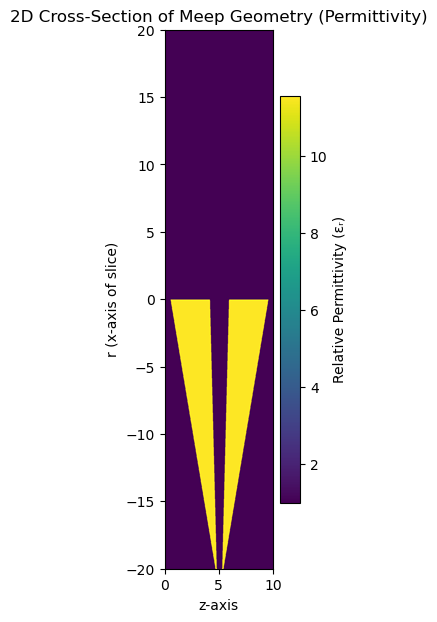

In [40]:
geom2 = []

# A hollow, tapered horn (last object is air, which carves out the first)
geom2.append(mp.Cone(
        center=mp.Vector3(0, 0, 2.5),
        height=5.0,
        radius=1.5,
        radius2=18.0,
        material=mp.Medium(index=3.4)
))
geom2.append(mp.Cone(
        center=mp.Vector3(0, 0, 2.5),
        height=5.0,
        radius=1.0,
        radius2=3.5,
        material=mp.air  # This creates the hollow part
))


# Visualize the 2D cross-section of the defined geometry
plot_meep_cross_section(geom2, x_range=(-20, 20), z_range=(0, 10))


### Try to ring geometry

In [20]:
geom3 = [mp.Block(center=mp.Vector3(r + (w / 2)),
                     size=mp.Vector3(w, 1e20, 1e20),
                     material=mp.Medium(index=n))]

# Visualize the 2D cross-section of the defined geometry
plot_meep_cross_section(geom3, x_range=(-20, 20), z_range=(0, 10))

TypeError: plot_meep_cross_section() got an unexpected keyword argument 'x_range'

In [43]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

def get_permittivity(material):
    """Helper function to get a scalar permittivity for plotting."""
    if material == mp.metal:
        # Use a large value for metal to make it distinct in the plot
        return 1e4
    if isinstance(material, mp.Medium):
        if hasattr(material, 'index') and material.index != 1.0:
            return material.index**2
        if hasattr(material, 'epsilon_diag'):
            # Assuming isotropic medium for visualization
            return material.epsilon_diag[0]
    # Default to air (permittivity of 1.0)
    return 1.0

def plot_meep_cross_section(ax, geometry, plane, slice_pos, range1, range2, resolution=500):
    """
    Calculates and plots a 2D cross-section of a Meep geometry list onto a given Matplotlib axis.

    ax: Matplotlib axis object to plot on.
    geometry: List of Meep geometry objects.
    plane: The plane to slice ('xy', 'yz', or 'xz').
    slice_pos: The position of the slice along the axis not in the plane.
    range1, range2: The (min, max) tuples for the two axes in the plane.
    resolution: The resolution of the grid for calculation.
    """
    # Define grid based on the specified plane
    axis_labels = [plane[0], plane[1]]
    min1, max1 = range1
    min2, max2 = range2
    
    v1 = np.linspace(min1, max1, resolution)
    v2 = np.linspace(min2, max2, resolution)
    V1, V2 = np.meshgrid(v1, v2, indexing='ij')
    
    eps = np.ones_like(V1)

    for obj in geometry:
        eps_val = get_permittivity(obj.material)
        cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
        
        # Initialize an empty mask for the object
        mask = np.zeros_like(eps, dtype=bool)

        # --- XY Plane ---
        if plane == 'xy':
            X, Y = V1, V2
            sz = getattr(obj, 'height', getattr(obj, 'size', [0,0,0])[2])
            if abs(slice_pos - cz) > sz / 2 and not isinstance(obj, mp.Sphere):
                continue
            
            if isinstance(obj, mp.Cone):
                t = (slice_pos - (cz - obj.height/2)) / obj.height
                r_at_z = obj.radius + t * (obj.radius2 - obj.radius)
                mask = (X - cx)**2 + (Y - cy)**2 <= r_at_z**2
            elif isinstance(obj, mp.Cylinder):
                mask = (X - cx)**2 + (Y - cy)**2 <= obj.radius**2
            elif isinstance(obj, mp.Block):
                mask = (np.abs(X - cx) <= obj.size.x/2) & (np.abs(Y - cy) <= obj.size.y/2)
            elif isinstance(obj, mp.Sphere):
                d_sq = (slice_pos - cz)**2
                if d_sq <= obj.radius**2:
                    r_slice_sq = obj.radius**2 - d_sq
                    mask = (X - cx)**2 + (Y - cy)**2 <= r_slice_sq

        # --- YZ or XZ Plane (similar logic) ---
        else: # yz or xz
            Z = V2
            if plane == 'yz':
                Y = V1
                slice_axis_pos, obj_axis_pos = slice_pos, cx
                obj_axis_size = getattr(obj, 'size', [0,0,0])[0]
            else: # xz
                X = V1
                slice_axis_pos, obj_axis_pos = slice_pos, cy
                obj_axis_size = getattr(obj, 'size', [0,0,0])[1]

            if isinstance(obj, mp.Cone):
                mask_z = np.abs(Z - cz) <= obj.height/2
                t = (Z[mask_z] - (cz - obj.height/2)) / obj.height
                r_at_z = obj.radius + t * (obj.radius2 - obj.radius)
                
                # Check if the slice plane intersects the cone at this Z
                dist_sq = (slice_axis_pos - obj_axis_pos)**2
                width_sq = r_at_z**2 - dist_sq
                
                valid_z = width_sq >= 0
                half_width = np.sqrt(width_sq[valid_z])
                
                # Apply the mask for the other axis (X or Y)
                if plane == 'yz':
                    mask_y = np.abs(Y[mask_z][valid_z] - cy) <= half_width
                    full_mask = np.zeros_like(Z, dtype=bool)
                    full_mask[mask_z] = valid_z
                    full_mask[full_mask] = mask_y
                else: # xz
                    mask_x = np.abs(X[mask_z][valid_z] - cx) <= half_width
                    full_mask = np.zeros_like(Z, dtype=bool)
                    full_mask[mask_z] = valid_z
                    full_mask[full_mask] = mask_x
                mask = full_mask

            elif isinstance(obj, mp.Cylinder):
                 dist_sq = (slice_axis_pos - obj_axis_pos)**2
                 if dist_sq <= obj.radius**2:
                     half_width = np.sqrt(obj.radius**2 - dist_sq)
                     mask_z = np.abs(Z - cz) <= obj.height/2
                     if plane == 'yz': mask_v1 = np.abs(Y - cy) <= half_width
                     else: mask_v1 = np.abs(X - cx) <= half_width
                     mask = mask_v1 & mask_z
            
            elif isinstance(obj, mp.Block):
                if abs(slice_axis_pos - obj_axis_pos) <= obj_axis_size / 2:
                    mask_z = np.abs(Z - cz) <= obj.size.z/2
                    if plane == 'yz': mask_v1 = np.abs(Y - cy) <= obj.size.y/2
                    else: mask_v1 = np.abs(X - cx) <= obj.size.x/2
                    mask = mask_v1 & mask_z

            elif isinstance(obj, mp.Sphere):
                d_sq = (slice_axis_pos - obj_axis_pos)**2
                if d_sq <= obj.radius**2:
                    r_slice_sq = obj.radius**2 - d_sq
                    if plane == 'yz': mask = (Y - cy)**2 + (Z - cz)**2 <= r_slice_sq
                    else: mask = (X - cx)**2 + (Z - cz)**2 <= r_slice_sq
        
        eps[mask] = eps_val

    # --- Plotting ---
    extent = [min2, max2, min1, max1]
    im = ax.imshow(np.rot90(eps), extent=extent, cmap='viridis', aspect='auto', interpolation='spline16')
    ax.set_xlabel(f"{axis_labels[1]}-axis")
    ax.set_ylabel(f"{axis_labels[0]}-axis")
    ax.set_title(f"{plane.upper()} Plane at {plane.replace(axis_labels[0],'').replace(axis_labels[1],'')}={slice_pos}")
    return im

def visualize_all_panes(geometry, x_range, y_range, z_range, slice_positions):
    """
    Creates a 3-panel plot showing the XY, YZ, and XZ cross-sections of the geometry.

    geometry: List of Meep geometry objects.
    x_range, y_range, z_range: The (min, max) tuples for each axis.
    slice_positions: A tuple (x_slice, y_slice, z_slice) indicating where to
                     slice for the yz, xz, and xy planes respectively.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    plt.style.use('default')

    x_slice, y_slice, z_slice = slice_positions

    # Plot XY, YZ, and XZ planes
    im_xy = plot_meep_cross_section(axes[0], geometry, 'xy', slice_pos=z_slice, range1=x_range, range2=y_range)
    im_yz = plot_meep_cross_section(axes[1], geometry, 'yz', slice_pos=x_slice, range1=y_range, range2=z_range)
    im_xz = plot_meep_cross_section(axes[2], geometry, 'xz', slice_pos=y_slice, range1=x_range, range2=z_range)

    fig.suptitle("Orthogonal Cross-Sections of Meep Geometry", fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 0.9, 0.95]) # Adjust layout to make space for colorbar

    # Add a single colorbar for all subplots
    cbar = fig.colorbar(im_xz, ax=axes.ravel().tolist(), shrink=0.8, location='bottom')
    cbar.set_label("Relative Permittivity (εᵣ)")
    
    plt.show()

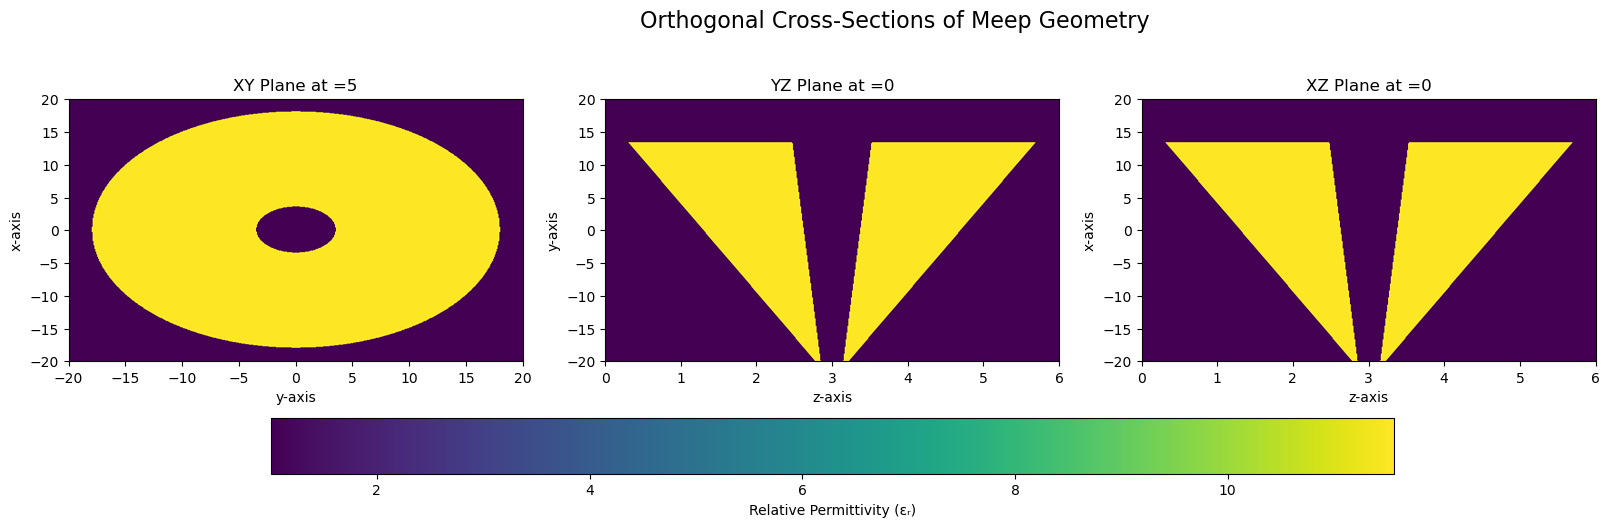

In [44]:
# Define ranges and slice positions for the plot
x_range = (-20, 20)
y_range = (-20, 20)
z_range = (0, 6)
# (slice_pos for YZ plane, slice_pos for XZ plane, slice_pos for XY plane)
slice_positions = (0, 0, 5) 

# Visualize the 3 orthogonal cross-sections with the new single function
visualize_all_panes(geom2, x_range, y_range, z_range, slice_positions)

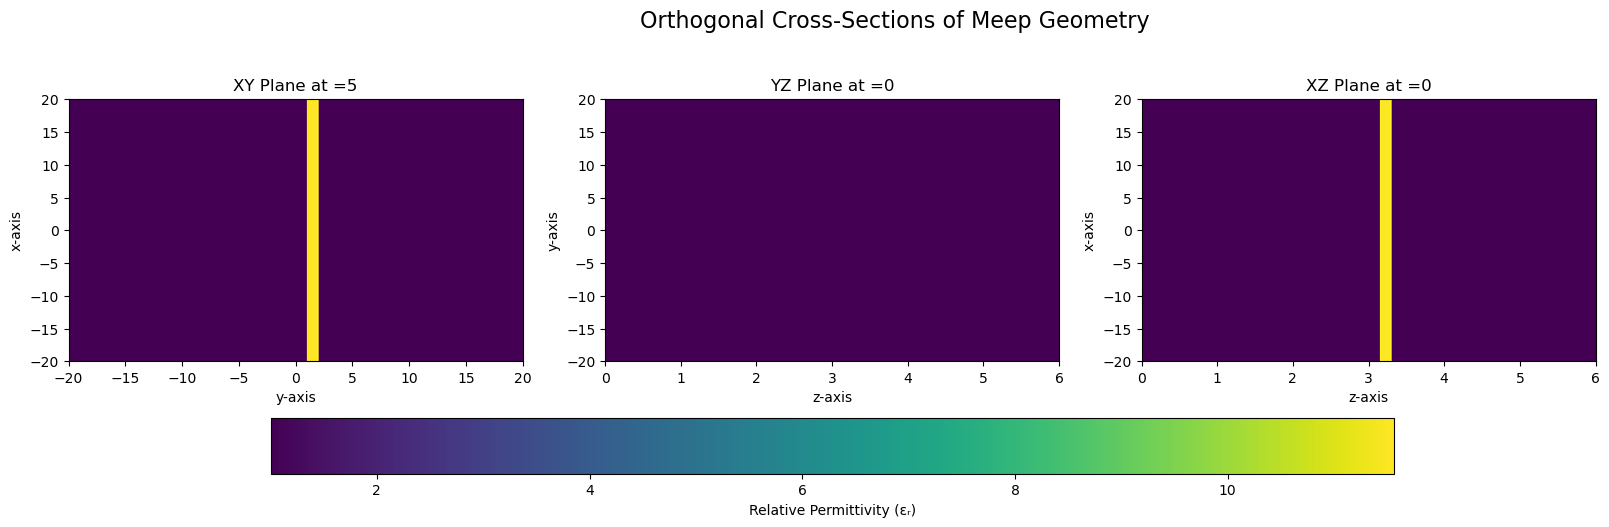

: 

In [45]:
geom3 = [mp.Block(center=mp.Vector3(r + (w / 2)),
                     size=mp.Vector3(w, 1e20, 1e20),
                     material=mp.Medium(index=n))]

# Define ranges and slice positions for the plot
x_range = (-20, 20)
y_range = (-20, 20)
z_range = (0, 6)
# (slice_pos for YZ plane, slice_pos for XZ plane, slice_pos for XY plane)
slice_positions = (0, 0, 5) 

# Visualize the 3 orthogonal cross-sections with the new single function
visualize_all_panes(geom3, x_range, y_range, z_range, slice_positions)